# Hierarchical Statistical Model: Block-level Amplitude

This notebook compares **12 frontal stimulation patients** with **10 controls** using
**hierarchical linear mixed-effects models** (LMM), measuring `relative_spike_amplitude` at the **block level** instead of the spike level.

### Fixed effects
- **group_label** : stimulation / control
- **block_type** : stimuli_block / pause_block
- **group_label × block_type** interaction

### Random effect
- Random intercept per **subject_id**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, wilcoxon
import utils

# ── Subject lists ──────────────────────────────────────────────
stim_subjects = [
    '485', '486', '487', '488', '497', '498',
    '499', '505', '5107', '515', '520', '545'
]

control_subjects = [
    '394', '396', '398', '402', '404',
    '405', '406', '415', '416', '417'
]

# ── Paths ────────────────────────────────────────────────────
STIM_FEAT_PATH = (
    r'D:\Ofer_backup\V6_model\p%s\unichannel_model'
    r'\min_amplitude_1\features\p%s_flat_features.csv'
)
STIM_ANN_PATH  = r'D:\Maya\clean Stim Project\P%s\P%s_annotations_ms.csv'

CTRL_FEAT_PATH = (
    r'D:\Ofer_backup\V6_model\controls\p%s\unichannel_model'
    r'\min_amplitude_1\features\p%s_flat_features.csv'
)
CTRL_ANN_PATH  = r'D:\UCLA\%s_clean_mtl_annot.fif'

# ── Feature columns ─────────────────────────────────────────
SPIKE_FEATURES = [
    'relative_spike_amplitude',
]

KEEP_COLS = (
    ['timestamp', 'channel', 'group', 'stimuli_flag', 'hypnogram_flag']
    + SPIKE_FEATURES
)

print('Setup done.')

Setup done.


## 1. Data Loading

In [2]:
def load_subject(subj, feat_path_template, ann_path_template, group_label,
                 ann_is_fif=False):
    """Load a single subject's flat-features CSV."""
    fp = feat_path_template % (subj, subj)
    if not os.path.exists(fp):
        print(f'  [SKIP] feature file not found: {fp}')
        return None

    df = pd.read_csv(fp)

    existing = [c for c in KEEP_COLS if c in df.columns]
    df = df[existing].copy()

    df = df.drop_duplicates(subset='group', keep='first')

    if ann_is_fif:
        ann_file = ann_path_template % subj
        if subj == '405':
            ann_file = ann_file.replace('_clean_mtl_annot.fif',
                                       '_clean_mtl_annot_cropped.fif')
    else:
        ann_file = ann_path_template % (subj, subj)

    try:
        df = utils.remove_noisy_samples_and_channels(
            subj, df, ann_file,
            ts_col='timestamp', channel_col='channel'
        )
    except Exception as e:
        print(f'  [WARN] noise removal failed for {subj}: {e}')

    df['subject_id']  = subj
    df['group_label'] = group_label
    return df

def build_block_info_stim(subj, df):
    mask = df['stimuli_flag'].isin(['stimuli_block', 'pause_block'])
    out = df.loc[mask].copy()
    out.rename(columns={'stimuli_flag': 'block_type'}, inplace=True)
    return out

def build_block_info_control(subj, df):
    epochs = utils.get_stim_starts_upgraded(subj)
    if not epochs:
        print(f'  [SKIP] no pseudo-blocks for control {subj}')
        return None

    rows = []
    for i, (start, end) in enumerate(epochs):
        blk = df[(df['timestamp'] > start * 1000) &
                 (df['timestamp'] < end   * 1000)].copy()
        blk['block_type']  = 'stimuli_block'
        blk['block_index'] = i
        rows.append(blk)

        if i + 1 < len(epochs):
            pause = df[(df['timestamp'] > end * 1000) &
                       (df['timestamp'] < epochs[i + 1][0] * 1000)].copy()
            pause['block_type']  = 'pause_block'
            pause['block_index'] = i
            rows.append(pause)

    if not rows:
        return None
    return pd.concat(rows, ignore_index=True)

print('Loading functions defined.')

Loading functions defined.


## 2. Build Block-Level Aggregated Dataset

In [3]:
all_block_frames  = []   # per-block observations (amplitude, etc.)

# ── Stimulation subjects ──────────────────────────────────
print('=== Loading STIMULATION subjects ===')
for subj in stim_subjects:
    print(f'  {subj} ...', end=' ')
    raw = load_subject(subj, STIM_FEAT_PATH, STIM_ANN_PATH,
                       group_label='stimulation')
    if raw is None or raw.empty:
        continue
    blk = build_block_info_stim(subj, raw)
    if blk is None or blk.empty:
        continue

    stim_epochs = utils.get_stim_starts(subj)
    for i, (start, end) in enumerate(stim_epochs):
        # stim block
        blk_stim = blk[(blk['timestamp'] > start * 1000) &
                       (blk['timestamp'] < end   * 1000) &
                       (blk['block_type'] == 'stimuli_block')]
        amp_stim = blk_stim['relative_spike_amplitude'].mean()
        
        if not np.isnan(amp_stim):
            all_block_frames.append({
                'subject_id': subj, 'group_label': 'stimulation',
                'block_type': 'stimuli_block', 'block_index': i,
                'relative_spike_amplitude': amp_stim
            })
            
        # pause block
        if i + 1 < len(stim_epochs):
            blk_pause = blk[(blk['timestamp'] > end * 1000) &
                            (blk['timestamp'] < stim_epochs[i+1][0] * 1000) &
                            (blk['block_type'] == 'pause_block')]
            amp_pause = blk_pause['relative_spike_amplitude'].mean()
            
            if not np.isnan(amp_pause):
                all_block_frames.append({
                    'subject_id': subj, 'group_label': 'stimulation',
                    'block_type': 'pause_block', 'block_index': i,
                    'relative_spike_amplitude': amp_pause
                })
    print(f'{len(blk)} spikes -> aggregated explicitly into blocks.')

# ── Control subjects ──────────────────────────────────────
print('\n=== Loading CONTROL subjects ===')
for subj in control_subjects:
    print(f'  {subj} ...', end=' ')
    raw = load_subject(subj, CTRL_FEAT_PATH, CTRL_ANN_PATH,
                       group_label='control', ann_is_fif=True)
    if raw is None or raw.empty:
        continue
    blk = build_block_info_control(subj, raw)
    if blk is None or blk.empty:
        continue

    epochs = utils.get_stim_starts_upgraded(subj)
    for i, (start, end) in enumerate(epochs):
        # stim block
        blk_stim = blk[(blk['timestamp'] > start * 1000) &
                       (blk['timestamp'] < end   * 1000) &
                       (blk['block_type'] == 'stimuli_block')]
        amp_stim = blk_stim['relative_spike_amplitude'].mean()
        
        if not np.isnan(amp_stim):
            all_block_frames.append({
                'subject_id': subj, 'group_label': 'control',
                'block_type': 'stimuli_block', 'block_index': i,
                'relative_spike_amplitude': amp_stim
            })
            
        if i + 1 < len(epochs):
            blk_pause = blk[(blk['timestamp'] > end * 1000) &
                            (blk['timestamp'] < epochs[i+1][0] * 1000) &
                            (blk['block_type'] == 'pause_block')]
            amp_pause = blk_pause['relative_spike_amplitude'].mean()
            
            if not np.isnan(amp_pause):
                all_block_frames.append({
                    'subject_id': subj, 'group_label': 'control',
                    'block_type': 'pause_block', 'block_index': i,
                    'relative_spike_amplitude': amp_pause
                })
    print(f'{len(blk)} spikes -> aggregated explicitly into blocks.')

# ── Merge ─────────────────────────────────────────────────
df_blocks = pd.DataFrame(all_block_frames)

print(f'\n--- Combined dataset ---')
print(f'  Block-level observations : {len(df_blocks)}')


=== Loading STIMULATION subjects ===
  485 ... 238 spikes -> aggregated explicitly into blocks.
  486 ... 227 spikes -> aggregated explicitly into blocks.
  487 ... 685 spikes -> aggregated explicitly into blocks.
  488 ... 836 spikes -> aggregated explicitly into blocks.
  497 ... 6935 spikes -> aggregated explicitly into blocks.
  498 ... 685 spikes -> aggregated explicitly into blocks.
  499 ... 136 spikes -> aggregated explicitly into blocks.
  505 ... 297 spikes -> aggregated explicitly into blocks.
  5107 ... 38 spikes -> aggregated explicitly into blocks.
  515 ... 112 spikes -> aggregated explicitly into blocks.
  520 ... Warning: bad-channels file not found: D:\Ofer_backup\bad_channels\p520_bad_channels.txt (keeping all channels)
529 spikes -> aggregated explicitly into blocks.
  545 ... 146 spikes -> aggregated explicitly into blocks.

=== Loading CONTROL subjects ===
  394 ... Opening raw data file D:\UCLA\394_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\394_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 29728999 =      0.000 ... 29728.999 secs
Ready.
1403 spikes -> aggregated explicitly into blocks.
  396 ... Opening raw data file D:\UCLA\396_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\396_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 25200999 =      0.000 ... 25200.999 secs
Ready.
376 spikes -> aggregated explicitly into blocks.
  398 ... Opening raw data file D:\UCLA\398_clean_mtl_annot.fif...


...

Isotrak not found
    Range : 0 ... 25546999 =      0.000 ... 25546.999 secs
Ready.
Opening raw data file D:\UCLA\415_clean_mtl_annot-1.fif...
Isotrak not found
    Range : 25547000 ... 27843999 =  25547.000 ... 27843.999 secs
Ready.
71 spikes -> aggregated explicitly into blocks.
  416 ... Opening raw data file D:\UCLA\416_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\416_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 27542999 =      0.000 ... 27542.999 secs
Ready.
1594 spikes -> aggregated explicitly into blocks.
  417 ... Opening raw data file D:\UCLA\417_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\417_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 31379999 =      0.000 ... 31379.999 secs
Ready.
318 spikes -> aggregated explicitly into blocks.

--- Combined dataset ---
  Block-level observations : 295


## 3. Hierarchical Mixed-Effects Models (Block Level)

Model formula:  `DV ~ C(group_label) * C(block_type)`, random intercept `(1 | subject_id)`

In [4]:
df_blocks

,subject_id,group_label,block_type,block_index,relative_spike_amplitude
0,485,stimulation,stimuli_block,0,3.397493
1,485,stimulation,pause_block,0,3.726531
2,485,stimulation,stimuli_block,1,4.994247
3,485,stimulation,pause_block,1,3.772729
4,485,stimulation,stimuli_block,2,2.303360
...,...,...,...,...,...
290,417,control,stimuli_block,5,2.759081
291,417,control,pause_block,5,2.953844
292,417,control,stimuli_block,6,2.794032
293,417,control,pause_block,6,2.319222


In [5]:
# df_blocks.to_csv('frontal_and_control_amp_blocks.csv', index=False)

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Model 1 – RELATIVE SPIKE AMPLITUDE (Block-level average)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('=' * 60)
print('MODEL: Block-average Relative Spike Amplitude')
print('=' * 60)

model_amp = smf.mixedlm(
    'relative_spike_amplitude ~ C(group_label, Treatment(reference="control")) * '
                                'C(block_type, Treatment(reference="pause_block"))',
    data=df_blocks,
    groups=df_blocks['subject_id'],
)
result_amp = model_amp.fit(reml=True)
print(result_amp.summary())

MODEL: Block-average Relative Spike Amplitude
                                                                   Mixed Linear Model Regression Results
Model:                                               MixedLM                                  Dependent Variable:                                  relative_spike_amplitude
No. Observations:                                    295                                      Method:                                              REML                    
No. Groups:                                          22                                       Scale:                                               0.4955                  
Min. group size:                                     7                                        Log-Likelihood:                                      -352.2734               
Max. group size:                                     29                                       Converged:                                           Yes           

## 4. Visualisation

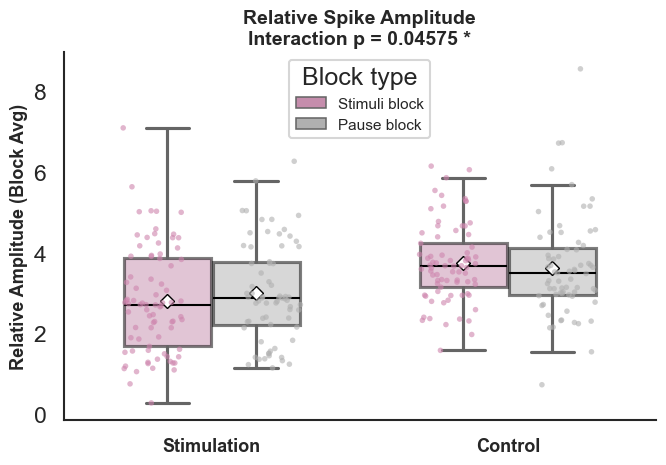

In [7]:
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'


def plot_interaction(data, y_col, y_label, model_result, title=''):
    """
    Grouped box-plot:  x = group_label, hue = block_type.
    Annotate with interaction p-value from the LMM.
    """
    sns.set(style='white', context='talk')
    fig, ax = plt.subplots(figsize=(7, 5))

    palette = {'stimuli_block': '#ce84ad', 'pause_block': '#b0b0b0'}

    sns.boxplot(
        data=data, x='group_label', y=y_col, hue='block_type',
        order=['stimulation', 'control'],
        hue_order=['stimuli_block', 'pause_block'],
        palette=palette,
        width=0.6, showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'white',
                   'markeredgecolor': 'black', 'markersize': 7},
        boxprops=dict(alpha=0.5, edgecolor='black'),
        medianprops=dict(color='black', linewidth=1.5),
        showfliers=False, zorder=2, ax=ax
    )

    sns.stripplot(
        data=data, x='group_label', y=y_col, hue='block_type',
        order=['stimulation', 'control'],
        hue_order=['stimuli_block', 'pause_block'],
        palette=palette, dodge=True,
        size=4, alpha=0.6, linewidth=0, zorder=3, ax=ax, jitter=0.2
    )

    # ── interaction p-value ──
    pvals = model_result.pvalues
    interaction_key = [k for k in pvals.index if 'group_label' in k and 'block_type' in k]
    if interaction_key:
        p_int = pvals[interaction_key[0]]
        ax.set_title(f'{title}\nInteraction p = {p_int:.4g} {p_to_stars(p_int)}',
                     fontsize=14, fontweight='bold')
    else:
        ax.set_title(title, fontsize=14, fontweight='bold')

    # clean up legend (strip duplicate entries from stripplot)
    handles, labels = ax.get_legend_handles_labels()
    n = len(handles) // 2
    ax.legend(handles[:n], ['Stimuli block', 'Pause block'],
              title='Block type', fontsize=11)

    ax.set_xlabel('')
    ax.set_xticklabels(['Stimulation', 'Control'], fontsize=13, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=13, fontweight='bold')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

plot_interaction(df_blocks, 'relative_spike_amplitude', 'Relative Amplitude (Block Avg)',
                 result_amp, 'Relative Spike Amplitude')

In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. טעינת הנתונים
# הקוד מניח שהקובץ נמצא באותה תיקייה
df_blocks = pd.read_csv('frontal_and_control_amp_blocks.csv')

# --- שלב הכנת הנתונים ---

# א. חישוב בייסליין לכל נבדק (ממוצע של כל בלוקי ה-Pause שלו)
baselines = df_blocks[df_blocks['block_type'] == 'pause_block'].groupby('subject_id')['relative_spike_amplitude'].mean().to_dict()

# ב. הוספת עמודת נרמול (אחוז שינוי של כל בלוק מהבייסליין של הנבדק)
df_blocks['baseline'] = df_blocks['subject_id'].map(baselines)
df_blocks['pct_normalized'] = ((df_blocks['relative_spike_amplitude'] - df_blocks['baseline']) / df_blocks['baseline']) * 100

# ג. יצירת דאטה ממוצע לרמת נבדק (Subject-level summary)
df_subj = df_blocks.groupby(['subject_id', 'group_label', 'block_type'])[['relative_spike_amplitude', 'pct_normalized']].mean().reset_index()

# ד. יצירת דאטה רחב לחישוב אחוז שינוי סופי (עבור מודל 8)
df_wide = df_subj.pivot_table(index=['subject_id', 'group_label'], 
                               columns='block_type', 
                               values='relative_spike_amplitude').reset_index()
df_wide['pct_change_final'] = ((df_wide['stimuli_block'] - df_wide['pause_block']) / df_wide['pause_block']) * 100

# ה. פיצול לקבוצת ניסוי בלבד עבור מודלים 1-4
df_stim_blocks = df_blocks[df_blocks['group_label'] == 'stimulation'].copy()
df_stim_subj = df_subj[df_subj['group_label'] == 'stimulation'].copy()

print("="*60)
print("הרצת 8 מודלים סטטיסטיים לאמפליטודה (רמת הבלוק)")
print("="*60)

# --- קבוצת הניסוי בלבד ---

# 1. מודל היררכי - גולמי (בלוקים)
res1 = smf.mixedlm("relative_spike_amplitude ~ block_type", df_stim_blocks, groups=df_stim_blocks["subject_id"]).fit()
print(f"1. ניסוי בלבד (בלוקים, גולמי): P={res1.pvalues['block_type[T.stimuli_block]']:.4f}, Coef={res1.params['block_type[T.stimuli_block]']:.3f}")

# 2. מודל היררכי - מנורמל (בלוקים)
res2 = smf.mixedlm("pct_normalized ~ block_type", df_stim_blocks, groups=df_stim_blocks["subject_id"]).fit()
print(f"2. ניסוי בלבד (בלוקים, מנורמל %): P={res2.pvalues['block_type[T.stimuli_block]']:.4f}, Coef={res2.params['block_type[T.stimuli_block]']:.2f}%")

# 3. מודל ממוצעים - גולמי (נבדקים)
res3 = smf.mixedlm("relative_spike_amplitude ~ block_type", df_stim_subj, groups=df_stim_subj["subject_id"]).fit()
print(f"3. ניסוי בלבד (נבדקים, גולמי): P={res3.pvalues['block_type[T.stimuli_block]']:.4f}, Coef={res3.params['block_type[T.stimuli_block]']:.3f}")

# 4. מודל ממוצעים - מנורמל (נבדקים)
res4 = smf.mixedlm("pct_normalized ~ block_type", df_stim_subj, groups=df_stim_subj["subject_id"]).fit()
print(f"4. ניסוי בלבד (נבדקים, מנורמל %): P={res4.pvalues['block_type[T.stimuli_block]']:.4f}, Coef={res4.params['block_type[T.stimuli_block]']:.2f}%")

print("-" * 30)

# --- שתי הקבוצות (Interaction Models) ---

# 5. שתי קבוצות - גולמי (בלוקים)
res5 = smf.mixedlm("relative_spike_amplitude ~ group_label * block_type", df_blocks, groups=df_blocks["subject_id"]).fit()
p5 = res5.pvalues.filter(like=':').values[0]
print(f"5. שתי קבוצות (בלוקים, גולמי) - אינטראקציה: P={p5:.4f}")

# 6. שתי קבוצות - מנורמל (בלוקים)
res6 = smf.mixedlm("pct_normalized ~ group_label * block_type", df_blocks, groups=df_blocks["subject_id"]).fit()
p6 = res6.pvalues.filter(like=':').values[0]
print(f"6. שתי קבוצות (בלוקים, מנורמל %) - אינטראקציה: P={p6:.4f}")

# 7. שתי קבוצות - גולמי (נבדקים)
res7 = smf.mixedlm("relative_spike_amplitude ~ group_label * block_type", df_subj, groups=df_subj["subject_id"]).fit()
p7 = res7.pvalues.filter(like=':').values[0]
print(f"7. שתי קבוצות (נבדקים, גולמי) - אינטראקציה: P={p7:.4f}")

# 8. שתי קבוצות - אחוז שינוי סופי (נבדקים)
res8 = smf.ols("pct_change_final ~ group_label", data=df_wide).fit()
p8 = res8.pvalues['group_label[T.stimulation]']
print(f"8. שתי קבוצות (נבדקים, אחוז שינוי סופי): P={p8:.4f}, Diff={res8.params['group_label[T.stimulation]']:.2f}%")

הרצת 8 מודלים סטטיסטיים לאמפליטודה (רמת הבלוק)
1. ניסוי בלבד (בלוקים, גולמי): P=0.0323, Coef=-0.234


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed t

2. ניסוי בלבד (בלוקים, מנורמל %): P=0.0191, Coef=-8.33%
3. ניסוי בלבד (נבדקים, גולמי): P=0.0204, Coef=-0.261
4. ניסוי בלבד (נבדקים, מנורמל %): P=0.0216, Coef=-9.53%
------------------------------
5. שתי קבוצות (בלוקים, גולמי) - אינטראקציה: P=0.0458
6. שתי קבוצות (בלוקים, מנורמל %) - אינטראקציה: P=0.0109
7. שתי קבוצות (נבדקים, גולמי) - אינטראקציה: P=0.0646
8. שתי קבוצות (נבדקים, אחוז שינוי סופי): P=0.0284, Diff=-14.34%


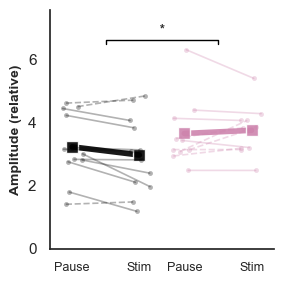

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# הגדרות סגנון
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")

# 1. טעינה והכנת נתונים (אמפליטודה ברמת בלוק)
df = pd.read_csv('frontal_and_control_amp_blocks.csv')

# מיצוע לרמת נבדק עבור הגרף
df_subj = (df[df.block_type.isin(['stimuli_block', 'pause_block'])]
           .groupby(['subject_id', 'group_label', 'block_type'])['relative_spike_amplitude']
           .mean()
           .unstack()
           .reset_index())

stim_grp = df_subj[df_subj.group_label == 'stimulation']
ctrl_grp = df_subj[df_subj.group_label == 'control']

# 2. יצירת הגרף
fig, ax = plt.subplots(figsize=(3,3))

c_stim = 'black'
c_ctrl = '#ce84ad'
jitter_val = 0.05 

def plot_enhanced_lines(data, x_base, color):
    # ציור הממוצע (הקו העבה)
    m_pause = data['pause_block'].mean()
    m_stim = data['stimuli_block'].mean()
    ax.plot(x_base, [m_pause, m_stim], '-s', color=color, linewidth=4, 
            markersize=9, zorder=3, markeredgecolor='white', alpha=0.9)

    # ציור הנבדקים הבודדים
    for _, row in data.iterrows():
        j = np.random.uniform(-jitter_val, jitter_val)
        x_pos = [x_base[0] + j, x_base[1] + j]
        
        # קו רציף לירידה, מקווקו לעלייה
        ls = '-' if row['stimuli_block'] < row['pause_block'] else '--'
        ax.plot(x_pos, [row['pause_block'], row['stimuli_block']],
                linestyle=ls, marker='o', color=color, alpha=0.3, 
                linewidth=1.2, markersize=3.5, zorder=4, markeredgecolor='none')

# ציור הקבוצות
plot_enhanced_lines(stim_grp, [0, 0.3], c_stim)
plot_enhanced_lines(ctrl_grp, [0.5, 0.8], c_ctrl)

# 3. סוגר אינטראקציה (מבוסס על P=0.0109 שמצאנו במודל 6)
y_max = df_subj[['pause_block', 'stimuli_block']].max().max()
y_bracket = y_max * 1.05
ax.plot([0.15, 0.15, 0.65, 0.65], [y_bracket * 0.98, y_bracket, y_bracket, y_bracket * 0.98], 
        color='black', linewidth=1)
ax.text(0.4, y_bracket * 1.02, f'*', 
        ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. עיצוב צירים
ax.set_xticks([0, 0.3, 0.5, 0.8])
ax.set_xticklabels(['Pause', 'Stim', 'Pause', 'Stim'], fontsize=9)
ax.set_ylabel('Amplitude (relative)', fontsize=10, fontweight='bold')
ax.set_xlim(-0.1, 0.9)
# התאמת גבול ה-Y לפי הנתונים המקסימליים
ax.set_ylim(0, y_max * 1.2)

sns.despine()
plt.tight_layout()
plt.show()

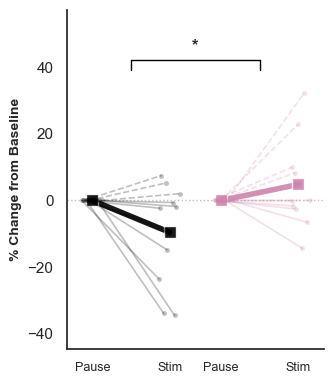

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. טעינה והכנת נתונים
df = pd.read_csv('frontal_and_control_amp_blocks.csv')

# מיצוע לרמת נבדק
df_subj = (df[df.block_type.isin(['stimuli_block', 'pause_block'])]
           .groupby(['subject_id', 'group_label', 'block_type'])['relative_spike_amplitude']
           .mean()
           .unstack()
           .reset_index())

# נרמול: ה-Pause הופך ל-0, וה-Stim הופך לאחוז שינוי מהבייסליין של עצמו
df_subj['pause_norm'] = 0
df_subj['stim_norm'] = ((df_subj['stimuli_block'] - df_subj['pause_block']) / df_subj['pause_block']) * 100

stim_grp = df_subj[df_subj.group_label == 'stimulation']
ctrl_grp = df_subj[df_subj.group_label == 'control']

# 2. יצירת הגרף
fig, ax = plt.subplots(figsize=(3.5, 4))

c_stim = 'black'
c_ctrl = '#ce84ad'
jitter_val = 0.05 

def plot_normalized_lines(data, x_base, color):
    # ממוצע הקבוצה
    m_pause = 0
    m_stim = data['stim_norm'].mean()
    
    # ציור הקו העבה (הממוצע)
    ax.plot(x_base, [m_pause, m_stim], '-s', color=color, linewidth=4, 
            markersize=9, zorder=3, markeredgecolor='white', alpha=0.9)

    # ציור הקווים של הנבדקים הבודדים
    for _, row in data.iterrows():
        j = np.random.uniform(-jitter_val, jitter_val)
        x_pos = [x_base[0] + j, x_base[1] + j]
        
        # קו רציף לירידה (מתחת ל-0), מקווקו לעלייה
        ls = '-' if row['stim_norm'] < 0 else '--'
        ax.plot(x_pos, [0, row['stim_norm']],
                linestyle=ls, marker='o', color=color, alpha=0.25, 
                linewidth=1.2, markersize=3.5, zorder=4, markeredgecolor='none')

# ציור שתי הקבוצות
plot_normalized_lines(stim_grp, [0, 0.3], c_stim)
plot_normalized_lines(ctrl_grp, [0.5, 0.8], c_ctrl)

# 3. עיצוב וסממנים סטטיסטיים
ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5) # קו ה-0 כייחוס
ax.set_xticks([0, 0.3, 0.5, 0.8])
ax.set_xticklabels(['Pause', 'Stim', 'Pause', 'Stim'], fontsize=9)
ax.set_ylabel('% Change from Baseline', fontsize=10, fontweight='bold')
ax.set_xlim(-0.1, 0.9)
ax.set_ylim(-40, 30)


# --- הוספת סוגר מובהקות בחלק העליון ---
y_max_val = max(df_subj['stim_norm'].max(), 0) # מוצא את הנקודה הכי גבוהה
y_bracket = y_max_val + 10 # קובע את גובה הסוגר מעליה

# ציור הסוגר (הקו המקשר)
ax.plot([0.15, 0.15, 0.65, 0.65], [y_bracket - 3, y_bracket, y_bracket, y_bracket - 3], 
        color='black', linewidth=1)
# ציור הכוכבית מעל הסוגר
ax.text(0.4, y_bracket + 2, f'*', ha='center', va='bottom', fontsize=12, fontweight='bold')

# התאמת גבולות הצירים כדי שיהיה מקום לסוגר למעלה
ax.set_ylim(df_subj['stim_norm'].min() - 10, y_bracket + 15)

sns.despine()
plt.tight_layout()
plt.show()

Variance reduction: 68.0%


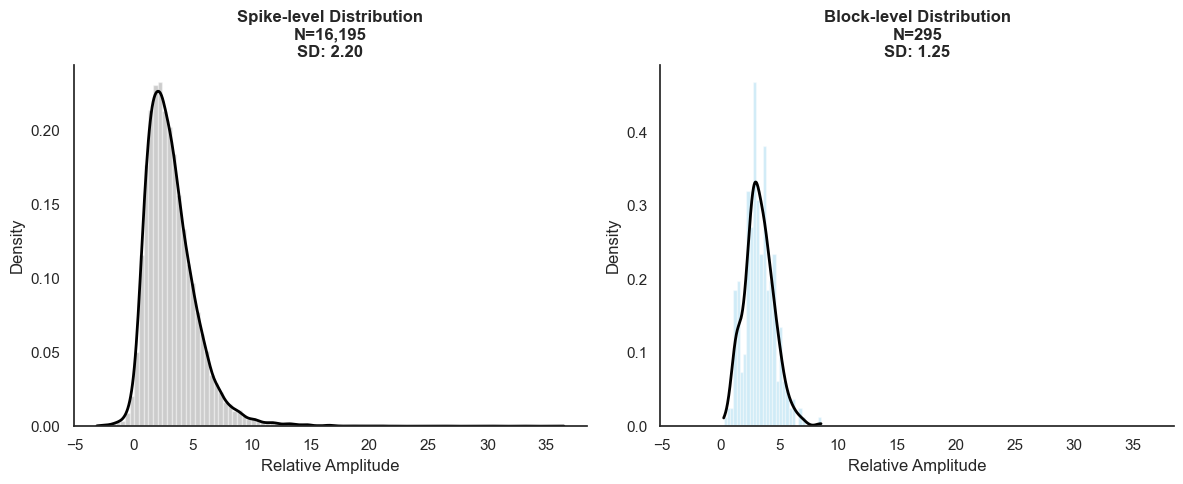

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# 1. טעינת הנתונים
df_spikes = pd.read_csv('frontal_and_control_amp.csv')
df_blocks = pd.read_csv('frontal_and_control_amp_blocks.csv')

# ניקוי ערכים
spikes_data = df_spikes['relative_spike_amplitude'].dropna().values
blocks_data = df_blocks['relative_spike_amplitude'].dropna().values

# הגדרות סגנון
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

def plot_hist_with_kde(data, ax, title, color, bins):
    # ציור ההיסטוגרמה הגולמית
    ax.hist(data, bins=bins, color=color, alpha=0.4, density=True, label='Histogram')
    
    # חישוב KDE ידני (במקום sns.kdeplot הבעייתי)
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_range, kde(x_range), color='black', linewidth=2, label='KDE Density')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Relative Amplitude")
    ax.set_ylabel("Density")

# ציור שני הגרפים
plot_hist_with_kde(spikes_data, axes[0], 
                   f"Spike-level Distribution\nN={len(spikes_data):,}\nSD: {spikes_data.std():.2f}", 
                   'gray', 100)

plot_hist_with_kde(blocks_data, axes[1], 
                   f"Block-level Distribution\nN={len(blocks_data):,}\nSD: {blocks_data.std():.2f}", 
                   'skyblue', 30)

# חישוב הפחתת השונות
reduction = (1 - (blocks_data.var() / spikes_data.var())) * 100
print(f"Variance reduction: {reduction:.1f}%")

sns.despine()
plt.tight_layout()
plt.show()

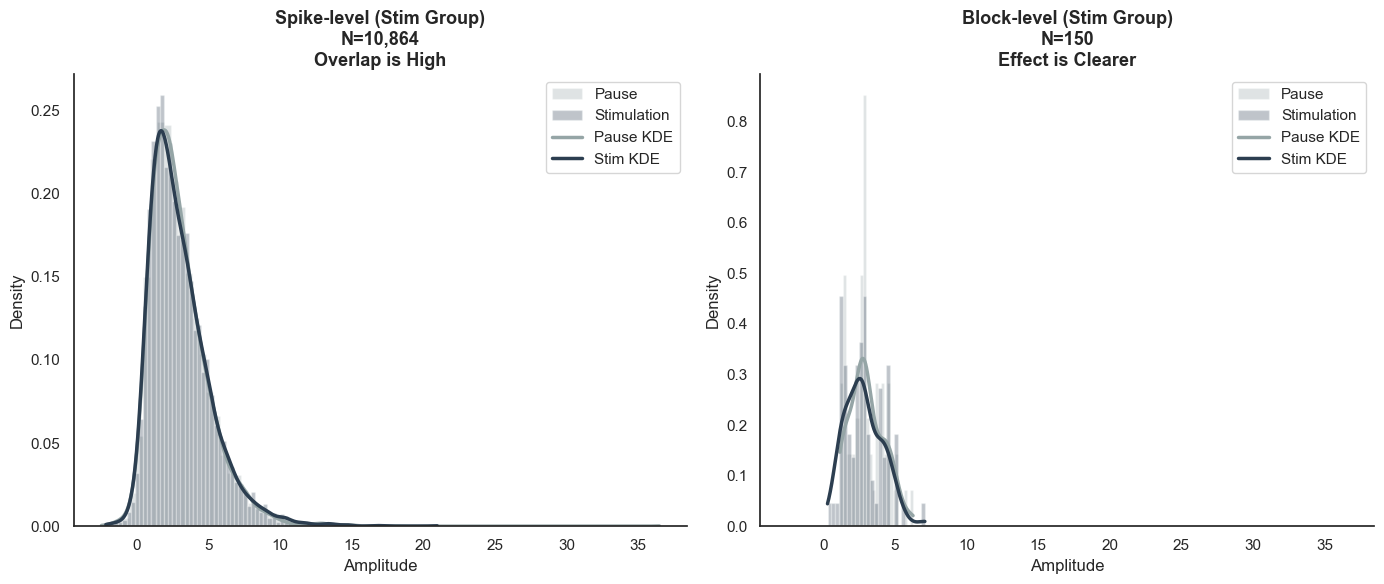

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# 1. טעינת הנתונים (התמקדות בקבוצת הניסוי בלבד כדי לראות את האפקט)
df_spikes = pd.read_csv('frontal_and_control_amp.csv')
df_blocks = pd.read_csv('frontal_and_control_amp_blocks.csv')

df_s_stim = df_spikes[df_spikes['group_label'] == 'stimulation']
df_b_stim = df_blocks[df_blocks['group_label'] == 'stimulation']

# הגדרות סגנון
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

def plot_comparison(data, ax, title, bins):
    # פיצול לגירוי והפסקה
    stim = data[data['block_type'] == 'stimuli_block']['relative_spike_amplitude'].dropna().values
    pause = data[data['block_type'] == 'pause_block']['relative_spike_amplitude'].dropna().values
    
    # הגדרת צבעים
    c_pause = '#95a5a6' # אפור
    c_stim = '#2c3e50'  # שחור/כחול כהה
    
    # ציור היסטוגרמות
    ax.hist(pause, bins=bins, color=c_pause, alpha=0.3, density=True, label='Pause')
    ax.hist(stim, bins=bins, color=c_stim, alpha=0.3, density=True, label='Stimulation')
    
    # חישוב KDE ידני למניעת שגיאת פנדס
    for arr, color, lab in zip([pause, stim], [c_pause, c_stim], ['Pause', 'Stim']):
        kde = gaussian_kde(arr)
        x_range = np.linspace(arr.min(), arr.max(), 500)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=f'{lab} KDE')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()

# גרף 1: רמת הספייק (כאן נראה חפיפה כמעט מלאה)
plot_comparison(df_s_stim, axes[0], 
                f"Spike-level (Stim Group)\nN={len(df_s_stim):,}\nOverlap is High", 80)

# גרף 2: רמת הבלוק (כאן נראה את ההפרדה/היסט)
plot_comparison(df_b_stim, axes[1], 
                f"Block-level (Stim Group)\nN={len(df_b_stim):,}\nEffect is Clearer", 25)

axes[0].set_ylabel("Density")
axes[1].set_ylabel("Density")
axes[0].set_xlabel("Amplitude")
axes[1].set_xlabel("Amplitude")

sns.despine()
plt.tight_layout()
plt.show()

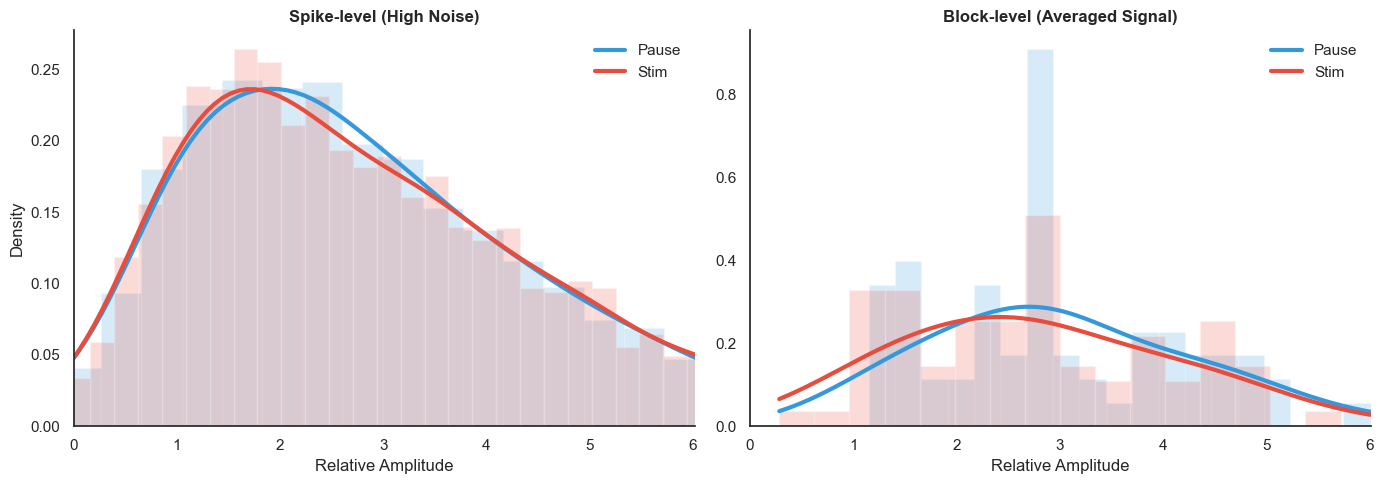

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# 1. טעינת הנתונים
df_spikes = pd.read_csv('frontal_and_control_amp.csv')
df_blocks = pd.read_csv('frontal_and_control_amp_blocks.csv')

# סינון לקבוצת הניסוי בלבד
df_s_stim = df_spikes[df_spikes['group_label'] == 'stimulation']
df_b_stim = df_blocks[df_blocks['group_label'] == 'stimulation']

# הגדרות סגנון
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

def plot_comparison_v2(data, ax, title, bins, bw_adj=0.5):
    # פיצול לגירוי והפסקה
    stim = data[data['block_type'] == 'stimuli_block']['relative_spike_amplitude'].dropna().values
    pause = data[data['block_type'] == 'pause_block']['relative_spike_amplitude'].dropna().values
    
    # צבעים עם קונטרסט גבוה
    c_pause = '#3498db' # כחול בהיר (Pause)
    c_stim = '#e74c3c'  # אדום (Stim)
    
    # ציור היסטוגרמות עם קצת יותר שקיפות
    ax.hist(pause, bins=bins, color=c_pause, alpha=0.2, density=True)
    ax.hist(stim, bins=bins, color=c_stim, alpha=0.2, density=True)
    
    # חישוב KDE ידני עם התאמת "רוחב פס" (bw_method) להחלקה טובה יותר
    for arr, color, lab in zip([pause, stim], [c_pause, c_stim], ['Pause', 'Stim']):
        if len(arr) > 1:
            # bw_method עוזר לקו להיראות פחות "שבור" כשיש מעט דאטה
            kde = gaussian_kde(arr, bw_method=bw_adj)
            x_range = np.linspace(data['relative_spike_amplitude'].min(), data['relative_spike_amplitude'].max(), 500)
            ax.plot(x_range, kde(x_range), color=color, linewidth=3, label=lab)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(frameon=False)

# גרף 1: רמת הספייק (כאן נשתמש בהחלקה רגילה)
plot_comparison_v2(df_s_stim, axes[0], "Spike-level (High Noise)", bins=100, bw_adj=0.2)

# גרף 2: רמת הבלוק (כאן נשתמש בהחלקה רחבה יותר כדי למנוע את המראה ה"מוזר")
plot_comparison_v2(df_b_stim, axes[1], "Block-level (Averaged Signal)", bins=20, bw_adj=0.6)

axes[0].set_ylabel("Density")
axes[0].set_xlabel("Relative Amplitude")
axes[1].set_xlabel("Relative Amplitude")

# הגבלת ציר ה-X כדי שנראה את מרכז המסה של הנתונים (נניח בין 0 ל-10)
ax_limit = df_b_stim['relative_spike_amplitude'].quantile(0.99)
plt.xlim(0, ax_limit)

sns.despine()
plt.tight_layout()
plt.show()

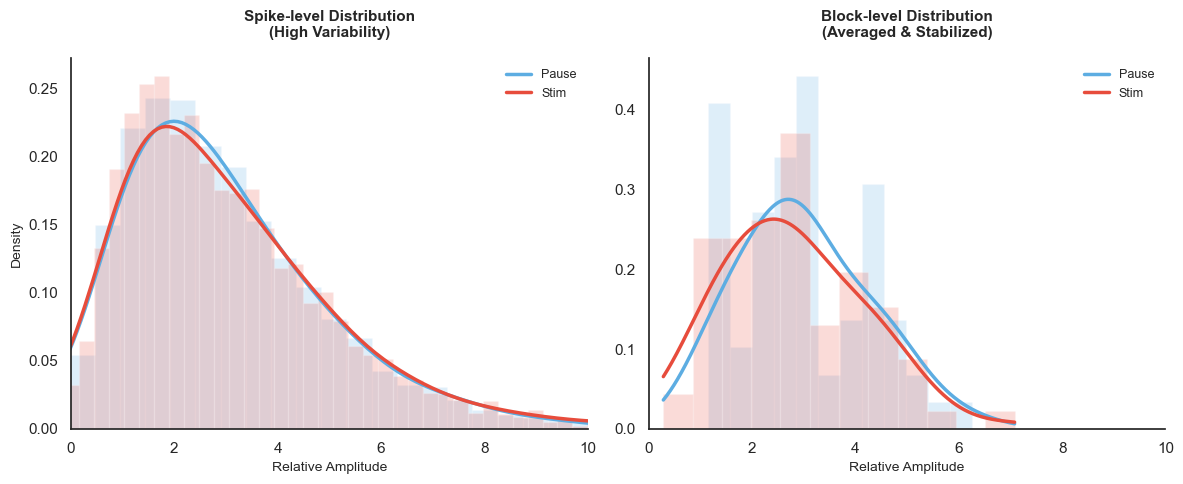

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# 1. טעינת הנתונים
df_spikes = pd.read_csv('frontal_and_control_amp.csv')
df_blocks = pd.read_csv('frontal_and_control_amp_blocks.csv')

# סינון לקבוצת הניסוי בלבד
df_s_stim = df_spikes[df_spikes['group_label'] == 'stimulation']
df_b_stim = df_blocks[df_blocks['group_label'] == 'stimulation']

# הגדרות סגנון
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

def plot_clean_comparison(data, ax, title, bins, bw_adj=0.5):
    stim = data[data['block_type'] == 'stimuli_block']['relative_spike_amplitude'].dropna().values
    pause = data[data['block_type'] == 'pause_block']['relative_spike_amplitude'].dropna().values
    
    # צבעים סולידיים ונעימים
    c_pause = '#5DADE2' # כחול
    c_stim = '#E74C3C'  # אדום
    
    # ציור ההיסטוגרמות עם פחות שקיפות ובלי קווי מתאר למראה נקי
    ax.hist(pause, bins=bins, color=c_pause, alpha=0.2, density=True)
    ax.hist(stim, bins=bins, color=c_stim, alpha=0.2, density=True)
    
    # הוספת קווי ה-KDE החלקים
    for arr, color, lab in zip([pause, stim], [c_pause, c_stim], ['Pause', 'Stim']):
        if len(arr) > 1:
            kde = gaussian_kde(arr, bw_method=bw_adj)
            # יצירת טווח רציף לציור הקו
            x_range = np.linspace(data['relative_spike_amplitude'].min(), 
                                  data['relative_spike_amplitude'].max(), 500)
            ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=lab)
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)

# גרף שמאל: ספייקים (הרבה bins כי יש המון דאטה)
plot_clean_comparison(df_s_stim, axes[0], "Spike-level Distribution\n(High Variability)", bins=80, bw_adj=0.3)

# גרף ימין: בלוקים (מעט bins למראה נקי ופחות "שבור")
plot_clean_comparison(df_b_stim, axes[1], "Block-level Distribution\n(Averaged & Stabilized)", bins=12, bw_adj=0.6)

# עיצוב סופי
axes[0].set_ylabel("Density", fontsize=10)
axes[0].set_xlabel("Relative Amplitude", fontsize=10)
axes[1].set_xlabel("Relative Amplitude", fontsize=10)

# הגבלת ציר ה-X לערכים רלוונטיים (למשל עד 10)
plt.xlim(0, 10)

sns.despine()
plt.tight_layout()
plt.show()